In [45]:
import numpy as np
import json
import pickle

from sklearn.datasets import make_multilabel_classification

from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier as BasePredictor

import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

In [ ]:
import sys

sys.path.append("..")

In [9]:
from src.data.formatting import resample_data_set
from src.conformal_risk_control.fnr import compute_prediction_set
from src.model_selection.fnr_oracle import compute_oracle_prediction_set
from src.model_selection.fnr_upper import compute_upper_prediction_set
from src.model_selection.fnr_split import select_predictor_index

In [10]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [46]:
def save_list_with_pickle(my_list, file_name):
    with open(file_name, "wb") as file:
        pickle.dump(my_list, file)

In [11]:
def generate_data_set(params):
    inputs_, outputs_ = make_multilabel_classification(
        n_samples=params["sample_size"] + 1,
        n_features=params["feature_number"],
        n_classes=params["label_number"],
        n_labels=params["avg_label_number"],
        allow_unlabeled=False,
        return_indicator=True,
    )
    return inputs_, outputs_

In [16]:
params_global = reader("params/experiment_1.json")

{'data': {'sample_size': 500, 'feature_number': 300, 'label_number': 10, 'avg_label_number': 4, 'cal_size': 0.3, 'proper_cal_size': 0.5}, 'predictor': {'n_estimators_min': 10, 'n_estimators_max': 100, 'criterion': ['gini', 'entropy'], 'lam_numbers': [14, 22, 32, 38]}, 'risk': {'control_level': 0.25}}


In [ ]:
complete_n_estimators_grid = np.arange(
    params_global["predictor"]["n_estimators_min"],
    params_global["predictor"]["n_estimators_max"] + 1,
)
np.random.shuffle(complete_n_estimators_grid)
n_estimators_grids = [
    complete_n_estimators_grid[: int(lam_number / 2)]
    for lam_number in params_global["predictor"]["lam_numbers"]
]
print(n_estimators_grids)

[array([10, 14, 22, 90, 56, 98, 81]), array([10, 14, 22, 90, 56, 98, 81, 35, 36, 63, 13]), array([10, 14, 22, 90, 56, 98, 81, 35, 36, 63, 13, 18, 61, 23, 27, 72]), array([10, 14, 22, 90, 56, 98, 81, 35, 36, 63, 13, 18, 61, 23, 27, 72, 21,
       39, 31])]


In [ ]:
parameter_grids = [
    np.array(
        [
            {"n_estimators": n_estimators, "criterion": criterion}
            for n_estimators in n_estimators_grid
            for criterion in params_global["predictor"]["criterion"]
        ],
        dtype=object,
    )
    for n_estimators_grid in n_estimators_grids
]
print(parameter_grids)

[array([{'n_estimators': np.int64(62), 'criterion': 'gini'},
       {'n_estimators': np.int64(62), 'criterion': 'entropy'},
       {'n_estimators': np.int64(21), 'criterion': 'gini'},
       {'n_estimators': np.int64(21), 'criterion': 'entropy'},
       {'n_estimators': np.int64(48), 'criterion': 'gini'},
       {'n_estimators': np.int64(48), 'criterion': 'entropy'},
       {'n_estimators': np.int64(27), 'criterion': 'gini'},
       {'n_estimators': np.int64(27), 'criterion': 'entropy'},
       {'n_estimators': np.int64(61), 'criterion': 'gini'},
       {'n_estimators': np.int64(61), 'criterion': 'entropy'},
       {'n_estimators': np.int64(79), 'criterion': 'gini'},
       {'n_estimators': np.int64(79), 'criterion': 'entropy'},
       {'n_estimators': np.int64(44), 'criterion': 'gini'},
       {'n_estimators': np.int64(44), 'criterion': 'entropy'}],
      dtype=object), array([{'n_estimators': np.int64(62), 'criterion': 'gini'},
       {'n_estimators': np.int64(62), 'criterion': 'entr

In [28]:
predictors_ = [
    [OneVsRestClassifier(BasePredictor(**parameter)) for parameter in parameter_grid]
    for parameter_grid in parameter_grids
]

In [29]:
rep_number = 100

In [ ]:
results_ = [
    {
        "size": {
            "Oracle": [],
            "Upper": [],
            "Split": [],
            "Output": [],
        },
        "FNR": {
            "Oracle": [],
            "Upper": [],
            "Split": [],
        },
    }
    for _ in predictors_
]

In [33]:
results_

[{'size': {'Oracle': [], 'Upper': [], 'Split': [], 'Output': []},
  'FNR': {'Oracle': [], 'Upper': [], 'Split': []}},
 {'size': {'Oracle': [], 'Upper': [], 'Split': [], 'Output': []},
  'FNR': {'Oracle': [], 'Upper': [], 'Split': []}},
 {'size': {'Oracle': [], 'Upper': [], 'Split': [], 'Output': []},
  'FNR': {'Oracle': [], 'Upper': [], 'Split': []}},
 {'size': {'Oracle': [], 'Upper': [], 'Split': [], 'Output': []},
  'FNR': {'Oracle': [], 'Upper': [], 'Split': []}}]

In [34]:
for predictors, results in zip(predictors_, results_):
    for rep_index in tqdm(range(rep_number)):
        inputs_, outputs_ = generate_data_set(params_global["data"])

        (
            (scaled_inputs_train, outputs_train),
            (scaled_inputs_calibration, outputs_calibration),
            (
                scaled_inputs_selection,
                scaled_inputs_proper_cal,
                outputs_selection,
                outputs_proper_cal,
            ),
            (scaled_input_test, output_test),
        ) = resample_data_set(
            inputs_,
            outputs_,
            params_global["data"]["cal_size"],
            params_global["data"]["proper_cal_size"],
        )

        for predictor in predictors:
            predictor.fit(scaled_inputs_train, outputs_train)

        probas_calibration_per_predictor = [
            predictor.predict_proba(scaled_inputs_calibration)
            for predictor in predictors
        ]
        proba_test_per_predictor = [
            predictor.predict_proba(scaled_input_test) for predictor in predictors
        ]
        oracle_prediction_set = compute_oracle_prediction_set(
            outputs_calibration,
            probas_calibration_per_predictor,
            output_test,
            proba_test_per_predictor,
            params_global["risk"]["control_level"],
        )

        upper_prediction_set = compute_upper_prediction_set(
            outputs_calibration,
            probas_calibration_per_predictor,
            proba_test_per_predictor,
            params_global["risk"]["control_level"],
        )

        probas_selection_per_predictor = [
            predictor.predict_proba(scaled_inputs_selection) for predictor in predictors
        ]
        split_predictor_index = select_predictor_index(
            outputs_selection,
            probas_selection_per_predictor,
            params_global["risk"]["control_level"],
        )
        split_prediction_set = compute_prediction_set(
            predictors[split_predictor_index],
            scaled_inputs_proper_cal,
            outputs_proper_cal,
            scaled_input_test,
            params_global["risk"]["control_level"],
        )

        oracle_fnr = (
            np.logical_and(output_test, np.logical_not(oracle_prediction_set)).sum(
                axis=1
            )
            / output_test.sum(axis=1)
        ).item()
        upper_fnr = (
            np.logical_and(output_test, np.logical_not(upper_prediction_set)).sum(
                axis=1
            )
            / output_test.sum(axis=1)
        ).item()
        split_fnr = (
            np.logical_and(output_test, np.logical_not(split_prediction_set)).sum(
                axis=1
            )
            / output_test.sum(axis=1)
        ).item()

        results["FNR"]["Oracle"].append(oracle_fnr)
        results["FNR"]["Upper"].append(upper_fnr)
        results["FNR"]["Split"].append(split_fnr)

        results["size"]["Oracle"].append(oracle_prediction_set.sum())
        results["size"]["Upper"].append(upper_prediction_set.sum())
        results["size"]["Split"].append(split_prediction_set.sum())

  1%|          | 1/100 [00:13<22:58, 13.92s/it]

Average oracle prediction-set size: 3.0
Average output size: 2.0
Average split prediction-set size: 4.0
Average upper prediction-set size: 3.0


  2%|▏         | 2/100 [00:28<22:54, 14.02s/it]

Average oracle prediction-set size: 4.5
Average output size: 4.0
Average split prediction-set size: 5.0
Average upper prediction-set size: 4.5


  3%|▎         | 3/100 [00:41<22:24, 13.86s/it]

...

Average oracle prediction-set size: 5.214285714285714
Average output size: 3.877551020408163
Average split prediction-set size: 5.642857142857143
Average upper prediction-set size: 5.989795918367347


 99%|█████████▉| 99/100 [1:10:02<00:44, 44.07s/it]

Average oracle prediction-set size: 5.212121212121212
Average output size: 3.8686868686868685
Average split prediction-set size: 5.646464646464646
Average upper prediction-set size: 5.97979797979798


100%|██████████| 100/100 [1:10:46<00:00, 42.46s/it]

Average oracle prediction-set size: 5.19
Average output size: 3.87
Average split prediction-set size: 5.63
Average upper prediction-set size: 5.96


In [38]:
for results in results_:
    print(
        "Average oracle prediction-set size: {}".format(
            np.mean(results["size"]["Oracle"])
        )
    )
    print("Average output size: {}".format(np.mean(results["size"]["Output"])))
    print(
        "Average split prediction-set size: {}".format(
            np.mean(results["size"]["Split"])
        )
    )
    print(
        "Average upper prediction-set size: {}".format(
            np.mean(results["size"]["Upper"])
        )
    )
    print("\n")

Average oracle prediction-set size: 5.22
Average output size: 4.08
Average split prediction-set size: 5.65
Average upper prediction-set size: 5.69


Average oracle prediction-set size: 5.05
Average output size: 4.15
Average split prediction-set size: 5.48
Average upper prediction-set size: 5.88


Average oracle prediction-set size: 5.19
Average output size: 3.9
Average split prediction-set size: 5.49
Average upper prediction-set size: 5.85


Average oracle prediction-set size: 5.19
Average output size: 3.87
Average split prediction-set size: 5.63
Average upper prediction-set size: 5.96




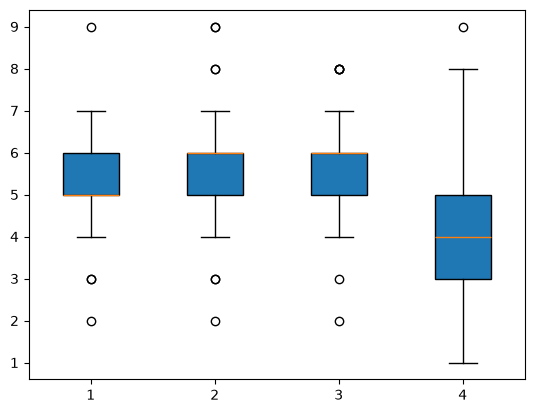

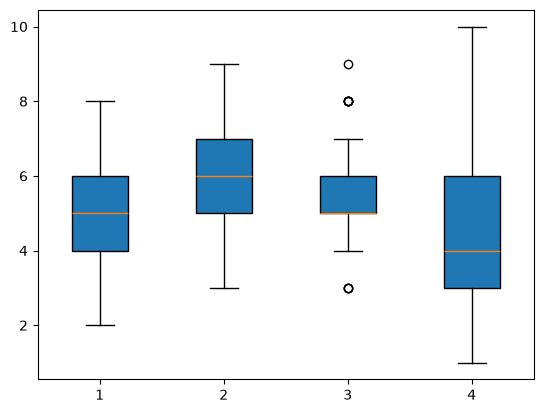

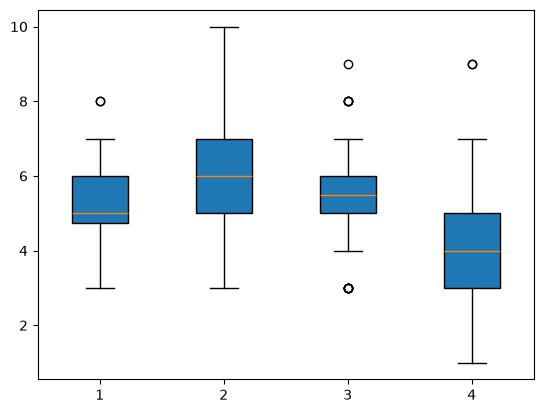

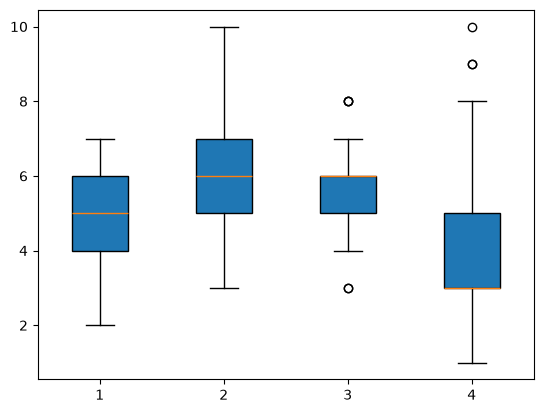

In [36]:
for results in results_:
    df_volume = pd.DataFrame.from_dict(results["size"])
    fig, ax = plt.subplots()
    box = ax.boxplot(df_volume, patch_artist=True)

In [ ]:
for results in results_:
    print(
        "Average oracle prediction-set FNR: {}".format(
            np.mean(results["FNR"]["Oracle"])
        )
    )
    print(
        "Average split prediction-set FNR: {}".format(np.mean(results["FNR"]["Split"]))
    )
    print(
        "Average upper prediction-set FNR: {}".format(np.mean(results["FNR"]["Upper"]))
    )
    print("\n")

Average oracle prediction-set FNR: 0.2740396825396825
Average split prediction-set FNR: 0.21996031746031747
Average upper prediction-set FNR: 0.22433730158730156


Average oracle prediction-set FNR: 0.249531746031746
Average split prediction-set FNR: 0.23839682539682538
Average upper prediction-set FNR: 0.19148809523809518


Average oracle prediction-set FNR: 0.2718095238095238
Average split prediction-set FNR: 0.2663253968253968
Average upper prediction-set FNR: 0.22654761904761903


Average oracle prediction-set FNR: 0.2434087301587301
Average split prediction-set FNR: 0.2148253968253968
Average upper prediction-set FNR: 0.17767460317460315




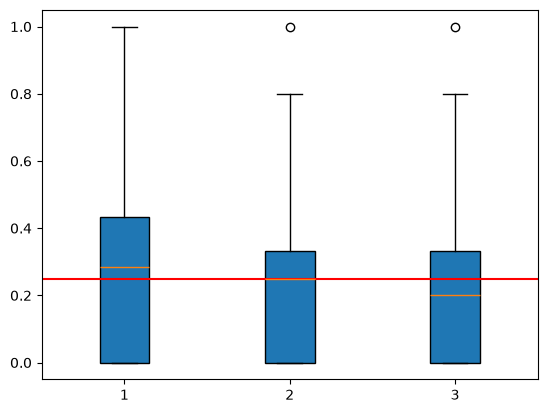

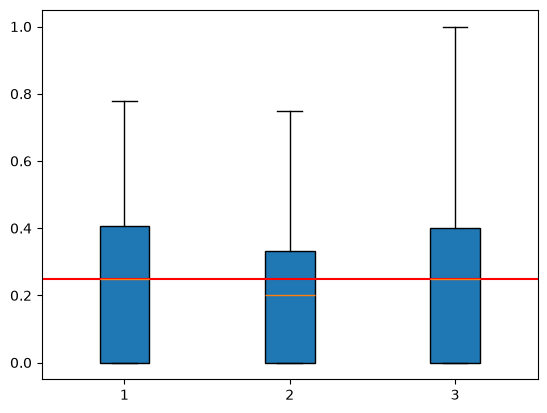

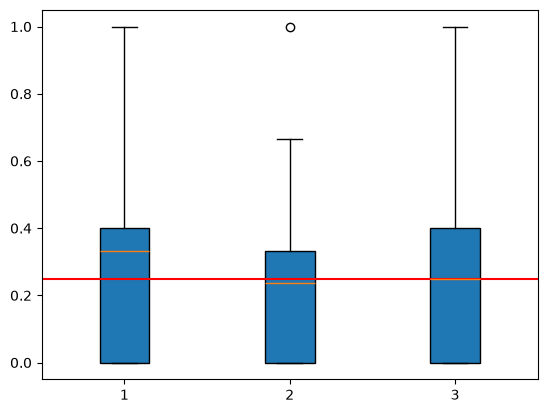

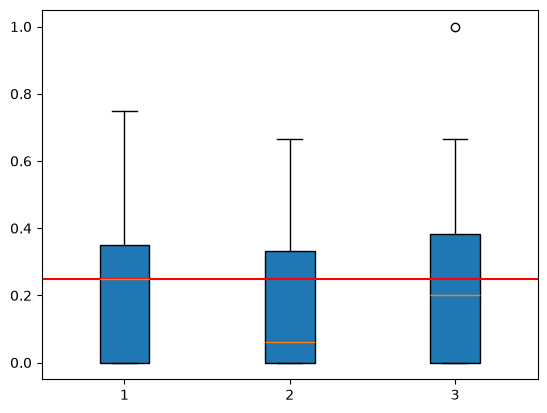

In [44]:
for results in results_:
    df_fnr = pd.DataFrame.from_dict(results["FNR"])
    fig, ax = plt.subplots()
    box = ax.boxplot(df_fnr, patch_artist=True)
    ax.plot(
        [1 - 0.5, 3 + 0.5],
        [
            params_global["risk"]["control_level"],
            params_global["risk"]["control_level"],
        ],
        color="red",
    )

In [47]:
result_path = "results/"
result_name = "experiment_1.pkl"
save_list_with_pickle(results_, result_path + result_name)